In [1]:
# Importing Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [2]:
# Reading the file
data = pd.read_csv(r"C:\Users\Disha\IISER - B Summer Internship\Brent Oil Futures Historical Data.csv")

In [3]:
# Converting "Vol." column to float datatype
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000
print(data.dtypes)

Date         object
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %     object
dtype: object


In [4]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

         Date  Price   Open   High    Low      Vol.
0  07/01/2019  65.06  65.05  66.75  64.22  361410.0
1  06/28/2019  66.55  66.51  66.84  66.08   34620.0
2  06/27/2019  66.55  66.05  66.82  65.63  103160.0
3  06/26/2019  66.49  65.80  66.85  65.60  141950.0
4  06/25/2019  65.05  64.89  65.98  64.17  205800.0


In [5]:
# extract features and target
X = data[['Open', 'High', 'Low']]
y = data['Price']

In [6]:
# reshape the target variable into a 2D array
y = y.values.reshape(-1, 1)

In [7]:
# split the data into training and test sets
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.02, random_state=42)

In [8]:
# create a linear regression model
LinReg = LinearRegression()

In [9]:
# fit the model to the training data
LinReg.fit(train_X, train_y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [10]:
# make predictions on the test data
pred = LinReg.predict(test_X)

In [11]:
# Calculate R-squared
score = LinReg.score(test_X, test_y)
print("R^2 Score:", score)

R^2 Score: 0.9996946889556316


In [12]:
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test_y, pred))
print("Root Mean Squared Error: ", rmse)

Root Mean Squared Error:  0.46754980978027433


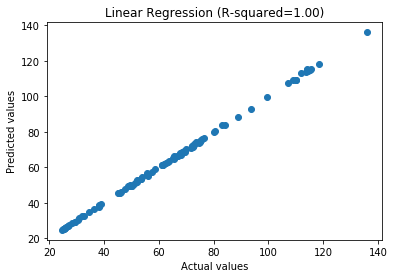

In [13]:
# Plot actual vs predicted values
import matplotlib.pyplot as plt

plt.scatter(test_y, pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Linear Regression (R-squared={score:.2f})")
plt.show()